In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
PROJECT_DIR = Path("/workspaces/DBA-ai-trust-score-framework-Interim")

SAMPLE_DIR = PROJECT_DIR / "data" / "samples"

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

REPORT_DIR = PROJECT_DIR / "reports"

FIGURE_DIR = REPORT_DIR / "figures"

PROCESSED_DIR.mkdir(exist_ok=True)

REPORT_DIR.mkdir(exist_ok=True)

FIGURE_DIR.mkdir(exist_ok=True)

In [3]:
metadata = pd.read_csv(
    SAMPLE_DIR / "metadata.csv"
)

metadata.head()

,file_name,label,dataset,original_path
0,gB_7_s2_2019-03-11T14-12-25-01-00_ir_face_mp4-...,DangerousDriving,Thesis_dataset2,../data/raw/Thesis_dataset2/DangerousDriving/g...
1,gA_4_s2_ir_face_mp4-372_jpg.rf.448fec2e90c845f...,DangerousDriving,Thesis_dataset2,../data/raw/Thesis_dataset2/DangerousDriving/g...
2,gA_5_s2_ir_face_mp4-130_jpg.rf.1081aec5f8fd8da...,DangerousDriving,Thesis_dataset2,../data/raw/Thesis_dataset2/DangerousDriving/g...
3,gB_9_s2_2019-03-07T16-21-20-01-00_ir_face_mp4-...,DangerousDriving,Thesis_dataset2,../data/raw/Thesis_dataset2/DangerousDriving/g...
4,gA_5_s2_ir_face_mp4-246_jpg.rf.f7bcf481f361e68...,DangerousDriving,Thesis_dataset2,../data/raw/Thesis_dataset2/DangerousDriving/g...


In [4]:
print("Rows :", metadata.shape[0])

print("Columns :", metadata.shape[1])

metadata.info()

Rows : 1400
Columns : 4
<class 'pandas.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   file_name      1400 non-null   str  
 1   label          1400 non-null   str  
 2   dataset        1400 non-null   str  
 3   original_path  1400 non-null   str  
dtypes: str(4)
memory usage: 268.7 KB


In [5]:
summary = pd.DataFrame({

    "Metric":[

        "Total Images",

        "Number of Classes",

        "Unique File Names"

    ],

    "Value":[

        len(metadata),

        metadata["label"].nunique(),

        metadata["file_name"].nunique()

    ]

})

summary

,Metric,Value
0,Total Images,1400
1,Number of Classes,7
2,Unique File Names,1398


In [6]:
summary.to_csv(

    REPORT_DIR / "dataset_summary.csv",

    index=False

)

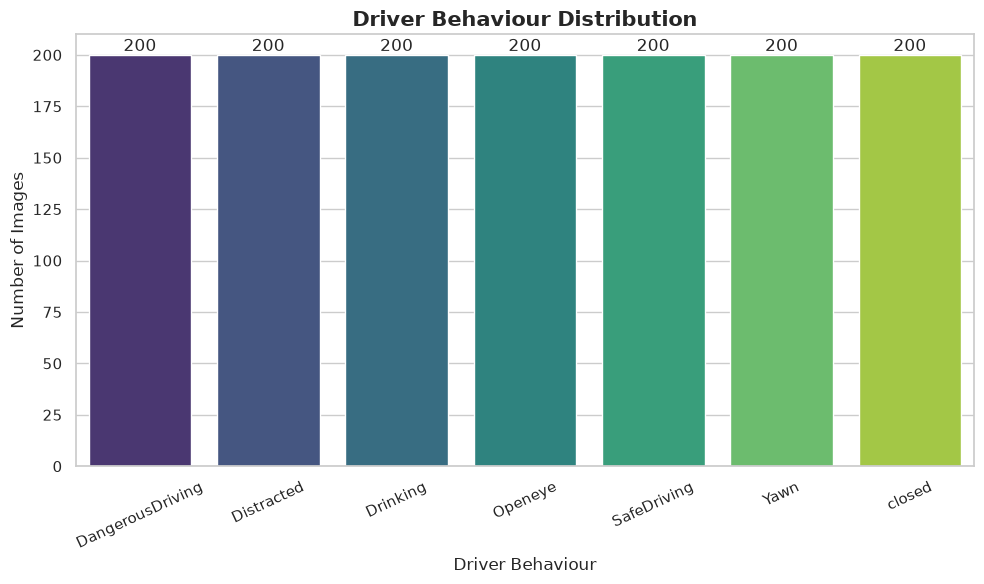

In [11]:
plt.figure(figsize=(10,6))

ax = sns.countplot(

    data=metadata,

    x="label",

    hue="label",

    palette="viridis",

    legend=False

)

plt.title(

    "Driver Behaviour Distribution",

    fontsize=15,

    fontweight="bold"

)

plt.xlabel("Driver Behaviour")

plt.ylabel("Number of Images")

plt.xticks(rotation=25)

for p in ax.patches:

    ax.annotate(

        str(int(p.get_height())),

        (

            p.get_x()+p.get_width()/2,

            p.get_height()

        ),

        ha="center",

        va="bottom"

    )

plt.tight_layout()

plt.savefig(

    FIGURE_DIR/"class_distribution.png",

    dpi=300

)

plt.show()

In [8]:
metadata.isnull().sum()

file_name        0
label            0
dataset          0
original_path    0
dtype: int64

In [9]:
metadata.duplicated().sum()

np.int64(0)

In [10]:
metadata.to_csv(

    PROCESSED_DIR / "master_metadata.csv",

    index=False

)

print("Master metadata saved.")

Master metadata saved.
